# Galpy Orbit Tracebacks for Hunt Clusters

This notebook is an introduction to orbit tracebacks with `galpy`.
It uses the Hunt&Reffert (2023) cluster catalog, selects a small clean sample of clusters,
and integrates their orbits backward for 50 Myr in the Milky Way using `MWPotential2014`.

## Imports

- `pandas` and `numpy` for table handling
- `astropy.coordinates.SkyCoord` to package positions and velocities with units
- `galpy.orbit.Orbit` to integrate orbits
- `galpy.potential.MWPotential2014` for a simple Milky Way potential
- `matplotlib` for quick plots

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.coordinates import SkyCoord

from galpy.orbit import Orbit
from galpy.potential import MWPotential2014

## Configuration

The Hunt catalog path below matches the one used in the existing project notebooks.
If your file lives somewhere else, change `HUNT_CATALOG_PATH` and leave the rest of the notebook alone.

We will integrate from `0 Myr` to `-50 Myr` in steps of `0.5 Myr`.
Negative time means "in the past", and `0 Myr` means the present day.

In [18]:
HUNT_CATALOG_PATH = Path('/Users/cam/Downloads/hunt_catalog_oct_13.csv')

TIME_START_MYR = 0.0
TIME_STOP_MYR = -50.0
TIME_STEP_MYR = 0.5
N_SAMPLE = 6

RO_KPC = 8.122 # GC distance from the Sun in kpc
VO_KMS = 236.0 # Circular velocity at the Sun in km/s
ZO_KPC = 0.0208 # Sun's height above the Galactic plane in kpc

# A descending time grid that starts at the present day and traces backward.
time_myr = np.arange(TIME_START_MYR, TIME_STOP_MYR - TIME_STEP_MYR, -TIME_STEP_MYR)

print(f'Catalog exists: {HUNT_CATALOG_PATH.exists()}')
print(f'{len(time_myr)} time steps from {time_myr[0]} to {time_myr[-1]} Myr')

Catalog exists: True
101 time steps from 0.0 to -50.0 Myr


## Load and standardize the Hunt catalog

The Hunt file uses the column names you have been using elsewhere in this repo:

- positions: `x_hunt_50`, `y_hunt_50`, `z_hunt_50` in pc
- velocities: `U_new`, `V_new`, `W_new` in km/s
- cluster size: `n_stars_hunt`

For the rest of the notebook we rename those into the simpler columns
`x`, `y`, `z`, `U`, `V`, `W`, and `n_stars`.

In [19]:
column_renaming_dict = {
    'n_stars_hunt': 'n_stars',
    'U_new': 'U',
    'V_new': 'V',
    'W_new': 'W',
    'x_hunt_50': 'x',
    'y_hunt_50': 'y',
    'z_hunt_50': 'z',
    'U_err_new': 'U_err',
    'V_err_new': 'V_err',
    'W_err_new': 'W_err',
}

required_columns = ['name', 'age_myr', 'x', 'y', 'z', 'U', 'V', 'W']

hunt_raw = pd.read_csv(HUNT_CATALOG_PATH)
hunt = hunt_raw.rename(columns=column_renaming_dict).copy()

missing = [col for col in required_columns if col not in hunt.columns]
if missing:
    raise ValueError(f'Missing required columns after renaming: {missing}')

hunt = hunt.dropna(subset=required_columns).copy()
for col in ['age_myr', 'x', 'y', 'z', 'U', 'V', 'W']:
    hunt[col] = pd.to_numeric(hunt[col], errors='coerce')

hunt = hunt.dropna(subset=required_columns).copy()

print(f'Rows in raw catalog: {len(hunt_raw):,}')
print(f'Rows with complete phase-space information: {len(hunt):,}')

hunt[required_columns + [c for c in ['family', 'n_stars'] if c in hunt.columns]].head()

Rows in raw catalog: 7,167
Rows with complete phase-space information: 4,802


,name,age_myr,x,y,z,U,V,W,n_stars
0,1636-283,307.578889,5869.824663,-834.322579,1270.657838,8.745882,-231.999282,-114.715629,38
1,ADS_16795,56.909672,-78.951939,190.523180,-9.610793,-13.076861,-19.651073,-3.686109,41
2,AH03_J0748+26.9,115.276398,-1793.949783,-3551.450718,-43.581177,-104.176343,-36.148781,-11.773779,68
5,ASCC_9,29.217331,-1702.715928,1543.566444,-69.548298,30.893940,-36.874977,-10.637951,136
6,ASCC_11,234.191029,-709.895654,400.794856,-132.592299,8.510804,-16.521095,-5.463504,315


## Pick a small demonstration sample

For a first teaching notebook, it is easier to follow a small deterministic sample rather than the full catalog.
Here we select a clean subset by requiring:

- positive cluster ages
- finite phase-space information
- reasonably local positions so the plots stay readable

Then we sort by age and name and keep the first few clusters.
If you want a custom sample later, replace this selection with `hunt.loc[hunt['name'].isin([...])]`.

In [20]:
sample = hunt.loc[
    (hunt['age_myr'] > 0)
    & hunt['x'].between(-1000, 1000)
    & hunt['y'].between(-1000, 1000)
    & hunt['z'].between(-300, 300)
].copy()

if 'U_err' in sample.columns and 'V_err' in sample.columns and 'W_err' in sample.columns:
    sample = sample.loc[
        (sample['U_err'] < 5)
        & (sample['V_err'] < 5)
        & (sample['W_err'] < 5)
    ].copy()

sample = sample.sort_values(['age_myr', 'name']).head(N_SAMPLE).reset_index(drop=True)

sample[['name', 'age_myr', 'x', 'y', 'z', 'U', 'V', 'W'] + [c for c in ['family', 'n_stars'] if c in sample.columns]]

,name,age_myr,x,y,z,U,V,W,n_stars
0,HSC_816,2.936511,-221.905307,843.074457,51.615801,16.407342,-25.048786,-12.587860,11
1,OC_0227,3.130413,-356.785599,599.298761,33.121985,0.584415,-13.267958,-11.119691,43
2,Alessi-Teutsch_10,3.423489,-352.397871,112.666434,-131.360823,-18.536893,-5.464610,-9.758363,85
3,IC_1396,3.570863,-146.032849,891.884156,59.034655,25.109888,-18.250006,-9.699800,693
4,OCSN_100,3.616197,126.208349,-12.197705,53.680636,-5.181673,-15.205420,-8.760267,87
5,Sigma_Orionis,3.732194,-337.396254,-170.702123,-117.915248,-25.574714,-15.690739,-6.722080,181


## Step 1: package each cluster as an `astropy` `SkyCoord`

`galpy` needs six-dimensional phase-space information: three positions and three velocities.
A convenient way to package that information is with `SkyCoord`, because it keeps the units attached.

In this notebook the coordinates are already in Galactic Cartesian form:

- `x`, `y`, `z` are heliocentric Cartesian positions in pc
- `U`, `V`, `W` are heliocentric Cartesian velocities in km/s

That is why we use `frame='galactic'` together with Cartesian representations.

In [21]:
cluster_coords = SkyCoord(
    u=sample['x'].to_numpy() * u.pc,
    v=sample['y'].to_numpy() * u.pc,
    w=sample['z'].to_numpy() * u.pc,
    U=sample['U'].to_numpy() * u.km / u.s,
    V=sample['V'].to_numpy() * u.km / u.s,
    W=sample['W'].to_numpy() * u.km / u.s,
    frame='galactic',
    representation_type='cartesian',
    differential_type='cartesian',
)

cluster_coords

<SkyCoord (Galactic): (u, v, w) in pc
    [(-221.90530668,  843.07445658,   51.61580059),
     (-356.78559885,  599.29876079,   33.12198452),
     (-352.39787112,  112.66643386, -131.36082302),
     (-146.03284903,  891.88415594,   59.03465479),
     ( 126.20834861,  -12.19770462,   53.68063557),
     (-337.39625415, -170.70212311, -117.91524818)]
 (U, V, W) in km / s
    [( 16.40734153, -25.04878639, -12.58786009),
     (  0.58441526, -13.2679582 , -11.11969135),
     (-18.53689343,  -5.46460993,  -9.75836255),
     ( 25.10988823, -18.25000648,  -9.69980022),
     ( -5.18167343, -15.20542047,  -8.76026704),
     (-25.57471407, -15.69073931,  -6.72208029)]>

## Step 2: build a `galpy` `Orbit`

The `Orbit` object combines the present-day phase-space coordinates with a Galactic scaling.

- `ro = 8.122 kpc`
- `vo = 236 km/s`
- `zo = 0.0208 kpc`

We also use `solarmotion='schoenrich'`, which tells `galpy` how to convert between the heliocentric input and the Galactic rest frame internally.

In [22]:
orbit = Orbit(
    vxvv=cluster_coords,
    ro=RO_KPC,
    vo=VO_KMS,
    zo=ZO_KPC,
    solarmotion='schoenrich',
)

orbit

## Step 3: integrate the orbits backward in time

This is the traceback step.
We integrate on the negative time grid defined above, using `MWPotential2014` as a simple Milky Way gravitational potential.

Because our time array runs from `0 Myr` to `-50 Myr`, the output positions trace each cluster backward from the present day into the past.

In [23]:
orbit.integrate(time_myr * u.Myr, MWPotential2014)

orbit_sc = orbit.SkyCoord(time_myr * u.Myr)

## Step 4: read out the galactocentric Cartesian coordinates

For visualizing the motion around the Galaxy, galactocentric Cartesian coordinates are often the clearest choice.
We therefore extract:

- `x_gc`
- `y_gc`
- `z_gc`

from the integrated orbit at every time step.

In [24]:
x_gc = np.asarray(orbit_sc.galactocentric.cartesian.x.to_value(u.kpc))
y_gc = np.asarray(orbit_sc.galactocentric.cartesian.y.to_value(u.kpc))
z_gc = np.asarray(orbit_sc.galactocentric.cartesian.z.to_value(u.kpc))

print('Array shape:', x_gc.shape)
print('Interpretation: (n_cluster, n_time)')

Array shape: (6, 101)
Interpretation: (n_cluster, n_time)


## Optional helper: convert the orbit arrays into a tidy table

This makes the output easier to inspect, group, and plot.

In [25]:
def build_orbit_table(sample_df, time_myr, x_gc, y_gc, z_gc):
    records = []
    for i, row in sample_df.iterrows():
        for j, t in enumerate(time_myr):
            records.append({
                'name': row['name'],
                'age_myr': row['age_myr'],
                'time_myr': t,
                'x_gc_kpc': x_gc[i, j],
                'y_gc_kpc': y_gc[i, j],
                'z_gc_kpc': z_gc[i, j],
            })
    return pd.DataFrame.from_records(records)

orbit_table = build_orbit_table(sample, time_myr, x_gc, y_gc, z_gc)
orbit_table.head()

,name,age_myr,time_myr,x_gc_kpc,y_gc_kpc,z_gc_kpc
0,HSC_816,2.936511,0.0,-8.343745,0.843075,0.072985
1,HSC_816,2.936511,-0.5,-8.356937,0.728862,0.075682
2,HSC_816,2.936511,-1.0,-8.368412,0.614499,0.078267
3,HSC_816,2.936511,-1.5,-8.378168,0.500010,0.080739
4,HSC_816,2.936511,-2.0,-8.386206,0.385419,0.083093


## Plot 1: the orbits projected onto the Galactic plane

This is usually the first traceback plot to show students.
The black star marks the Galactic center.
The large marker on each track is the present-day position at `t = 0 Myr`.

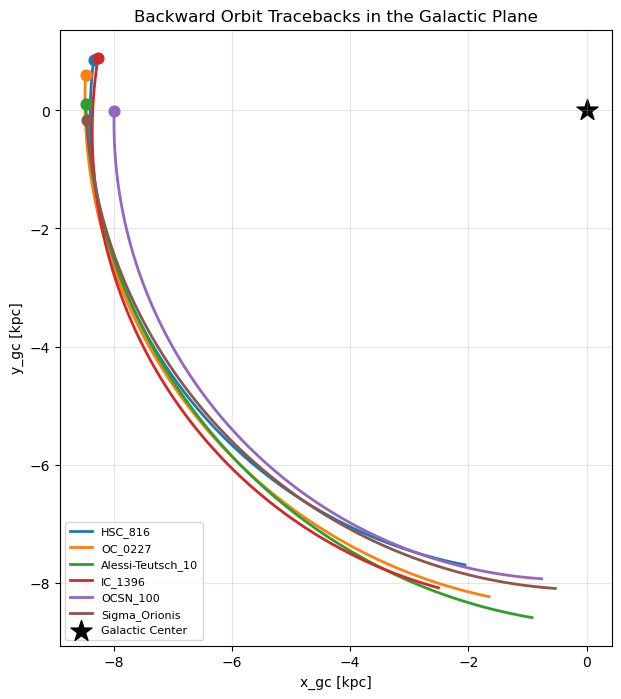

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

for i, row in sample.iterrows():
    ax.plot(x_gc[i], y_gc[i], lw=2, label=row['name'])
    ax.scatter(x_gc[i, 0], y_gc[i, 0], s=60, zorder=3)

ax.scatter(0, 0, marker='*', s=250, color='black', label='Galactic Center')
ax.set_xlabel('x_gc [kpc]')
ax.set_ylabel('y_gc [kpc]')
ax.set_title('Backward Orbit Tracebacks in the Galactic Plane')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.show()

## Plot 2: vertical motion relative to the Galactic plane

A second useful teaching view is `x_gc` versus `z_gc`, which shows how far each cluster moves above or below the disk.

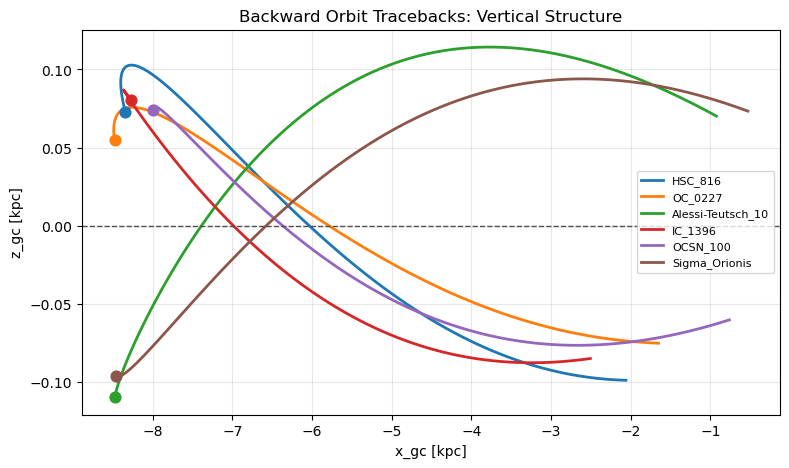

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for i, row in sample.iterrows():
    ax.plot(x_gc[i], z_gc[i], lw=2, label=row['name'])
    ax.scatter(x_gc[i, 0], z_gc[i, 0], s=60, zorder=3)

ax.axhline(0, color='0.3', lw=1, ls='--')
ax.set_xlabel('x_gc [kpc]')
ax.set_ylabel('z_gc [kpc]')
ax.set_title('Backward Orbit Tracebacks: Vertical Structure')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.show()

## Plot 3: a simple 3D Matplotlib view


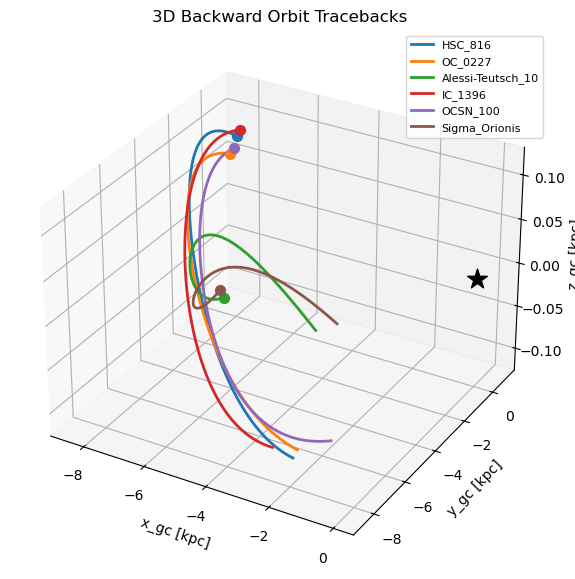

In [29]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, row in sample.iterrows():
    ax.plot(x_gc[i], y_gc[i], z_gc[i], lw=2, label=row['name'])
    ax.scatter(x_gc[i, 0], y_gc[i, 0], z_gc[i, 0], s=50)

ax.scatter(0, 0, 0, marker='*', s=220, color='black')
ax.set_xlabel('x_gc [kpc]')
ax.set_ylabel('y_gc [kpc]')
ax.set_zlabel('z_gc [kpc]')
ax.set_title('3D Backward Orbit Tracebacks')
ax.legend(loc='best', fontsize=8)
plt.show()